<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/languages/python/mini_projects/experiment_interactive_image_processing_pillow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Interactive Image Processor

This notebook will allow you to upload an image and then apply interactive transformations such as resizing and color changes. We'll use the `Pillow` (PIL) library for image manipulation, `IPython.display` for file uploads, and `ipywidgets` for interactive controls.

In [6]:
# Install necessary libraries if not already present
# !pip install Pillow ipywidgets matplotlib

import io
from PIL import Image, ImageOps, ImageFilter # Added ImageFilter
from IPython.display import display, FileLink, clear_output
from google.colab import files
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


#### Step 1: Upload Your Image

Run the cell below to upload an image file from your local system. Only one image can be processed at a time. The uploaded image will be stored in the `uploaded_img` variable.

Button(description='Upload Image', style=ButtonStyle())

Please upload an image file (e.g., JPG, PNG).


Saving IMG-20260212-WA0001.jpg to IMG-20260212-WA0001 (1).jpg
Successfully uploaded 'IMG-20260212-WA0001 (1).jpg'. Original image size: (1600, 1600)


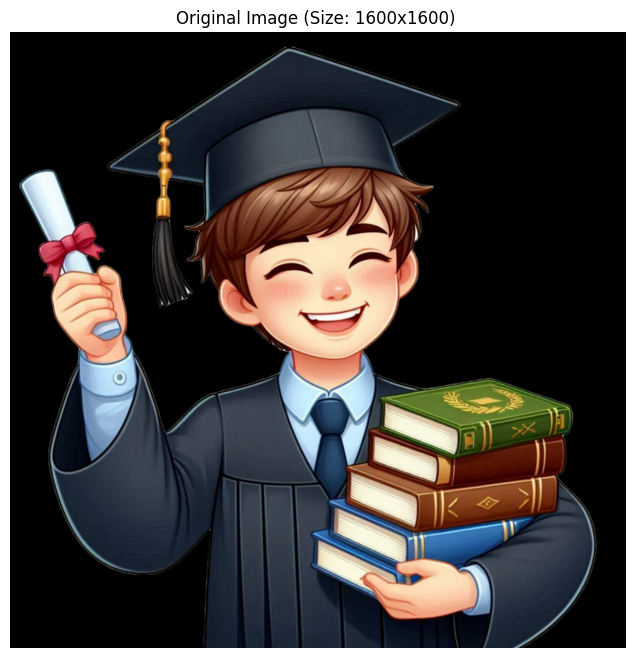

In [8]:
uploaded_img = None

def upload_image_and_process(event=None):
    global uploaded_img
    print("Please upload an image file (e.g., JPG, PNG).")
    uploaded = files.upload()

    if uploaded:
        filename = next(iter(uploaded))
        img_bytes = uploaded[filename]
        uploaded_img = Image.open(io.BytesIO(img_bytes))
        print(f"Successfully uploaded '{filename}'. Original image size: {uploaded_img.size}")
        display_original_image(uploaded_img)
    else:
        print("No file uploaded.")

def display_original_image(img):
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Original Image (Size: {img.size[0]}x{img.size[1]}) ")
    plt.axis('off')
    plt.show()

# Create an upload button
upload_button = widgets.Button(description="Upload Image")
upload_button.on_click(upload_image_and_process)
display(upload_button)

#### Step 2: Interact with the Image (Resize and Color)

Use the sliders and dropdown below to dynamically change the size and apply color filters to your uploaded image. Make sure you have uploaded an image in the previous step.

-   **Width / Height:** Adjust the dimensions of the image. The aspect ratio is maintained by default.
-   **Color Filter:** Apply 'Grayscale' or 'Sepia' filter, or view the 'Original' colors.

In [13]:
global last_processed_img

def process_and_display_image(width, height, crop_x1, crop_y1, crop_x2, crop_y2, color_filter):
    global uploaded_img
    global last_processed_img
    if uploaded_img is None:
        print("Please upload an image first using the 'Upload Image' button above.")
        return

    # Make a copy to avoid modifying the original during interactive operations
    processed_img = uploaded_img.copy()

    # Resizing
    original_width, original_height = processed_img.size
    if width != original_width or height != original_height:
        # Calculate new height to maintain aspect ratio if only one dimension is changed,
        # otherwise use both provided dimensions.
        target_width, target_height = width, height
        if width == original_width and height != original_height:
            target_width = int(original_width * (height / original_height))
        elif width != original_width and height == original_height:
            target_height = int(original_height * (width / original_width))

        processed_img = processed_img.resize((target_width, target_height), Image.Resampling.LANCZOS)

    # Cropping
    current_width, current_height = processed_img.size

    # Ensure crop coordinates are within the current image dimensions and valid
    final_crop_x1 = max(0, min(crop_x1, current_width - 1))
    final_crop_y1 = max(0, min(crop_y1, current_height - 1))
    final_crop_x2 = max(final_crop_x1 + 1, min(crop_x2, current_width))
    final_crop_y2 = max(final_crop_y1 + 1, min(crop_y2, current_height))

    if (final_crop_x1, final_crop_y1, final_crop_x2, final_crop_y2) != (0, 0, current_width, current_height):
        try:
            processed_img = processed_img.crop((final_crop_x1, final_crop_y1, final_crop_x2, final_crop_y2))
        except ValueError as e:
            print(f"Cropping error: {e}. Skipping crop for invalid dimensions.")

    # Color Filtering
    if color_filter == 'Grayscale':
        processed_img = ImageOps.grayscale(processed_img)
    elif color_filter == 'Sepia':
        processed_img = processed_img.convert('RGB')
        sepia_matrix = (
            0.393, 0.769, 0.189, 0,
            0.349, 0.686, 0.168, 0,
            0.272, 0.534, 0.131, 0
        )
        processed_img = processed_img.convert('RGB', sepia_matrix)
    elif color_filter == 'Invert':
        processed_img = ImageOps.invert(processed_img.convert('RGB'))
    elif color_filter == 'Blur':
        processed_img = processed_img.filter(ImageFilter.GaussianBlur(radius=2))
    elif color_filter == 'Sharpen':
        processed_img = processed_img.filter(ImageFilter.SHARPEN)

    last_processed_img = processed_img # Store the last processed image globally

    clear_output(wait=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(processed_img)
    plt.title(f"Processed Image ({processed_img.size[0]}x{processed_img.size[1]} | {color_filter})")
    plt.axis('off')
    plt.show()


# Initialize last_processed_img to None
last_processed_img = None

# Set up interactive widgets
if uploaded_img:
    original_width, original_height = uploaded_img.size
else:
    original_width, original_height = 800, 600 # Default values if no image uploaded yet

interact(
    process_and_display_image,
    width=widgets.IntSlider(min=50, max=original_width, step=50, value=original_width, description='Width'),
    height=widgets.IntSlider(min=50, max=original_height, step=50, value=original_height, description='Height'),
    crop_x1=widgets.IntSlider(min=0, max=original_width, step=1, value=0, description='Crop Left'),
    crop_y1=widgets.IntSlider(min=0, max=original_height, step=1, value=0, description='Crop Top'),
    crop_x2=widgets.IntSlider(min=1, max=original_width, step=1, value=original_width, description='Crop Right'),
    crop_y2=widgets.IntSlider(min=1, max=original_height, step=1, value=original_height, description='Crop Bottom'),
    color_filter=widgets.Dropdown(
        options=['Original', 'Grayscale', 'Sepia', 'Invert', 'Blur', 'Sharpen'],
        value='Original',
        description='Color Filter'
    )
);

interactive(children=(IntSlider(value=1600, description='Width', max=1600, min=50, step=50), IntSlider(value=1…

#### Step 3: Save and Download Processed Image

Use the input field below to specify a filename for your processed image. Once you click 'Save & Download', the last image displayed in Step 2 will be saved and downloaded to your local system. Supported formats are usually JPG, PNG, and TIFF.

In [15]:
def save_and_download_image(filename):
    global last_processed_img

    if last_processed_img is None:
        print("No image has been processed yet. Please interact with the image in Step 2 first.")
        return

    if not filename:
        print("Please provide a filename.")
        return

    try:
        # Ensure the image is in a format that can be saved directly, e.g., RGB
        # Some filters like grayscale might change the mode to 'L'. Convert back to 'RGB' if necessary for broad compatibility.
        if last_processed_img.mode == 'L':
            img_to_save = last_processed_img.convert('RGB')
        else:
            img_to_save = last_processed_img

        # Save image to a BytesIO object
        img_byte_arr = io.BytesIO()
        # Determine format from filename extension, default to PNG
        if '.' in filename:
            file_extension = filename.split('.')[-1].upper()
            if file_extension in ['JPG', 'JPEG']:
                img_to_save.save(img_byte_arr, format='JPEG')
            elif file_extension == 'PNG':
                img_to_save.save(img_byte_arr, format='PNG')
            elif file_extension == 'TIFF':
                img_to_save.save(img_byte_arr, format='TIFF')
            else:
                print(f"Unsupported file format '{file_extension}'. Saving as PNG.")
                filename = filename + '.png' if '.' not in filename else filename.rsplit('.', 1)[0] + '.png'
                img_to_save.save(img_byte_arr, format='PNG')
        else:
            # If no extension, save as PNG by default
            filename += '.png'
            img_to_save.save(img_byte_arr, format='PNG')

        img_byte_arr.seek(0)

        # Download the image
        files.download(filename=filename, content=img_byte_arr.getvalue())
        print(f"Image '{filename}' saved and downloaded successfully!")
    except Exception as e:
        print(f"Error saving or downloading image: {e}")


# Create an input field for filename and a button to trigger save and download
filename_input = widgets.Text(
    value='processed_image.png',
    placeholder='Enter filename (e.g., my_image.png)',
    description='Filename:',
    disabled=False
)

save_button = widgets.Button(description="Save & Download")

def on_save_button_click(b):
    save_and_download_image(filename_input.value)

save_button.on_click(on_save_button_click)

display(filename_input, save_button)


Text(value='processed_image.png', description='Filename:', placeholder='Enter filename (e.g., my_image.png)')

Button(description='Save & Download', style=ButtonStyle())